In [ ]:
import kagglehub

path = kagglehub.dataset_download("gauravtopre/bank-customer-churn-dataset")

print("Path to dataset files:", path)

100%|██████████| 187k/187k [00:00<00:00, 394kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/gauravtopre/bank-customer-churn-dataset/versions/1


In [ ]:
import pandas as pd
import os
import kagglehub
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

os.listdir(path)
df = pd.read_csv(path + "/Bank Customer Churn Prediction.csv")


# Tahap Data Understanding

In [ ]:
df.head() #data awal

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.tail() #data terakhir

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,15628319,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [ ]:
df.shape

(10000, 12)

In [ ]:
df.columns #melihat nama kolom

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [ ]:
#deskripsi setiap kolom
column_desc = pd.DataFrame({
    "Kolom":[
        "customer_id",
        "credit_score",
        "country",
        "gender",
        "age",
        "tenure",
        "balance",
        "products_number",
        "credit_card",
        "active_member",
        "estimated_salary",
        "churn"
    ],
    "Keterangan":[
        "ID pelanggan",
        "Skor kredit pelanggan",
        "Negara asal pelanggan",
        "Jenis kelamin",
        "Usia pelanggan",
        "Lama menjadi nasabah (tahun)",
        "Saldo rekening",
        "Jumlah produk yang dimiliki",
        "Kepemilikan kartu kredit",
        "Status pelanggan aktif",
        "Perkiraan gaji",
        "Status churn (0=bertahan,1=keluar)"
    ]
})

column_desc

,Kolom,Keterangan
0,customer_id,ID pelanggan
1,credit_score,Skor kredit pelanggan
2,country,Negara asal pelanggan
3,gender,Jenis kelamin
4,age,Usia pelanggan
5,tenure,Lama menjadi nasabah (tahun)
6,balance,Saldo rekening
7,products_number,Jumlah produk yang dimiliki
8,credit_card,Kepemilikan kartu kredit
9,active_member,Status pelanggan aktif


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [ ]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


  # TAHAP DATA CLENING

In [ ]:
df.isnull().sum() #cek data kosong

,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


In [ ]:
df.duplicated().sum() #cek data duplikat

np.int64(0)

In [ ]:
df.info() #cek tipe data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [ ]:
df.nunique() # cek melihat kode unik

,0
customer_id,10000
credit_score,460
country,3
gender,2
age,70
tenure,11
balance,6382
products_number,4
credit_card,2
active_member,2


In [ ]:
print(df["country"].unique())

print(df["gender"].unique()) # melihat nilai kategori

['France' 'Spain' 'Germany']
['Female' 'Male']


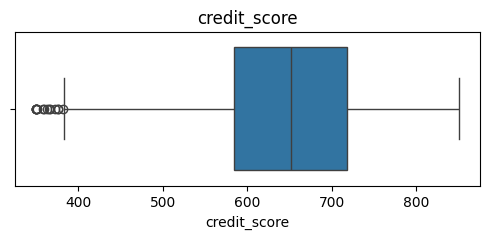

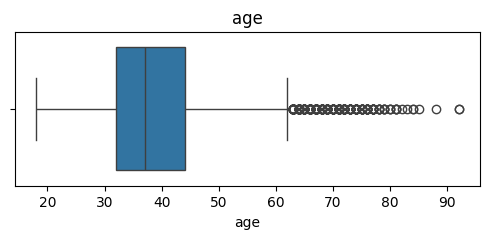

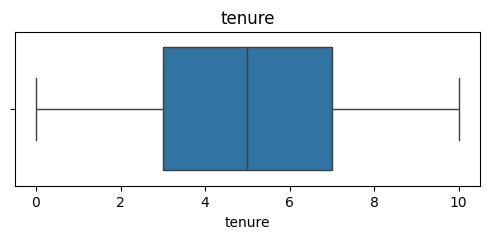

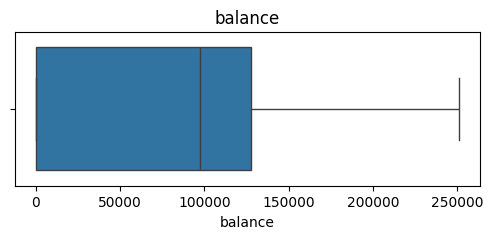

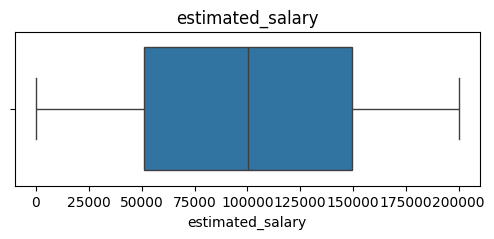

In [ ]:
numeric_columns = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "estimated_salary"
]

for col in numeric_columns:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

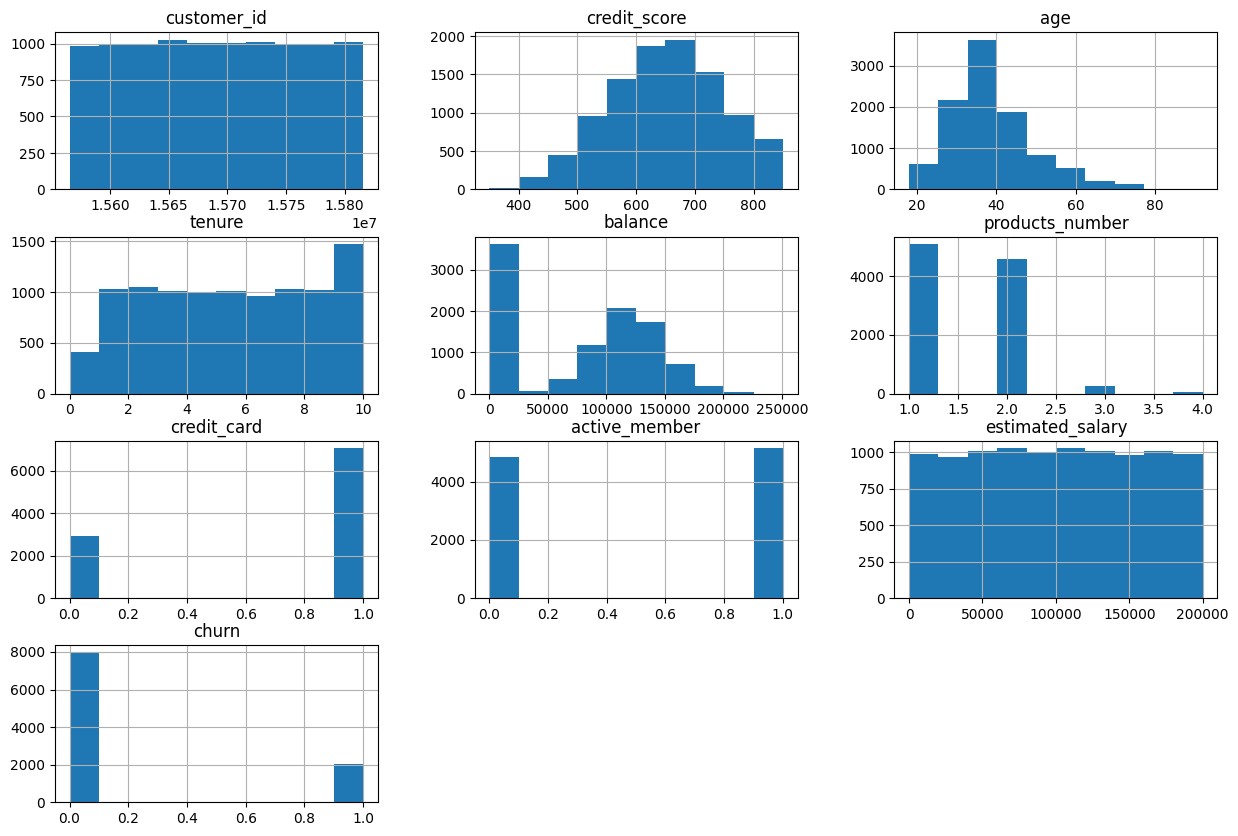

In [ ]:
df.hist(figsize=(15,10))

plt.show()

## Kesimpulan Distribusi Data

Berdasarkan hasil visualisasi histogram terhadap seluruh variabel pada dataset, diperoleh beberapa temuan sebagai berikut:

- Sebagian besar pelanggan memiliki credit score pada rentang 600–700, yang menunjukkan bahwa mayoritas pelanggan memiliki tingkat kelayakan kredit yang cukup baik.
- Variabel age didominasi oleh pelanggan berusia sekitar 30–45 tahun, sehingga kelompok usia produktif merupakan mayoritas nasabah bank.
- Variabel tenure menunjukkan penyebaran yang relatif merata dari 0 hingga 10 tahun, yang menandakan adanya pelanggan baru maupun pelanggan lama.
- Variabel balance menunjukkan banyak pelanggan memiliki saldo nol, sementara yang lainnya memiliki saldo pada kisaran 100.000–150.000. Hal ini mengindikasikan adanya perbedaan karakteristik penggunaan rekening.
- Variabel products_number didominasi oleh pelanggan yang hanya memiliki satu atau dua produk perbankan, sedangkan pelanggan dengan tiga atau empat produk jumlahnya sedikit.
- Sebagian besar pelanggan memiliki credit card, sedangkan distribusi active_member menunjukkan jumlah pelanggan aktif dan tidak aktif relatif seimbang.
- Variabel estimated_salary memiliki distribusi yang cukup merata sehingga belum terlihat adanya kelompok gaji tertentu yang mendominasi.
- Variabel target churn menunjukkan jumlah pelanggan yang bertahan (0) jauh lebih banyak dibandingkan pelanggan yang keluar (1). Hal ini mengindikasikan bahwa dataset memiliki distribusi kelas yang tidak seimbang.

# Tahapan Exploratory Data Analysis (EDA)

## Analisis 1 - Bagaimana Distribusi Customer Churn?

Bagaimana perbandingan jumlah pelanggan yang tetap menggunakan layanan bank dengan pelanggan yang melakukan churn?

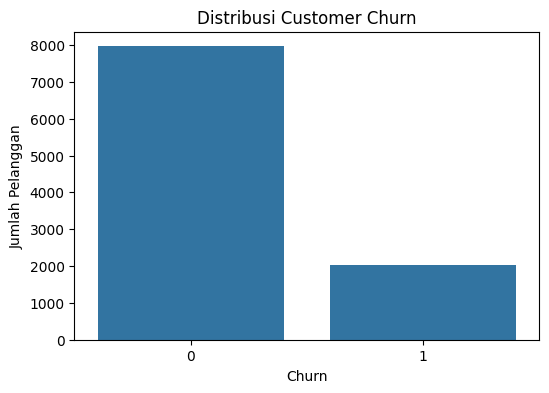

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="churn")

plt.title("Distribusi Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Jumlah Pelanggan")

plt.show()

In [ ]:
churn_percent = (
    df["churn"]
    .value_counts(normalize=True)
    *100
)

print(churn_percent)

churn
0    79.63
1    20.37
Name: proportion, dtype: float64


### Insight

Berdasarkan hasil visualisasi, sekitar 80% pelanggan masih bertahan, sedangkan sekitar 20% pelanggan telah berhenti menggunakan layanan bank (churn).

Hal ini menunjukkan bahwa tingkat churn masih cukup tinggi karena satu dari lima pelanggan memutuskan untuk meninggalkan layanan bank.

## Analisis 2 - Apakah Negara Berpengaruh terhadap Customer Churn?

Negara mana yang memiliki tingkat customer churn paling tinggi?

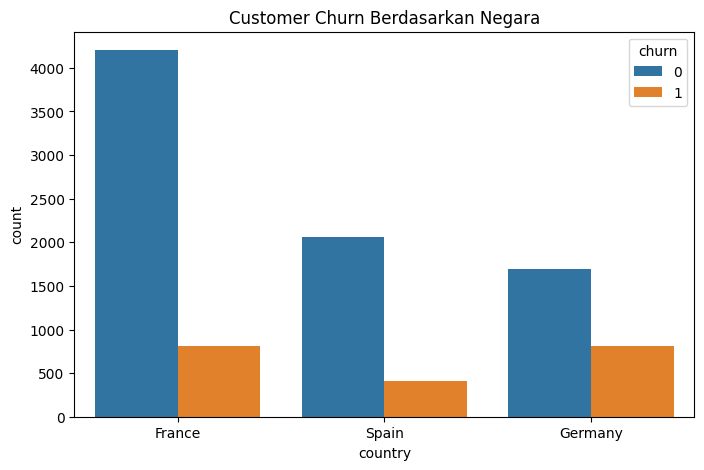

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="country",
    hue="churn"
)

plt.title("Customer Churn Berdasarkan Negara")

plt.show()

In [ ]:
pd.crosstab(
    df["country"],
    df["churn"],
    normalize="index"
)*100

churn,0,1
country,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


### Insight

Hasil analisis menunjukkan bahwa pelanggan dari Germany memiliki persentase customer churn paling tinggi dibandingkan negara lainnya.

Hal ini mengindikasikan adanya kemungkinan faktor-faktor tertentu di negara tersebut yang memengaruhi keputusan pelanggan untuk berhenti menggunakan layanan bank.

### Business Recommendation

Bank dapat melakukan evaluasi terhadap layanan pada negara dengan tingkat churn tertinggi.

## Analisis 3 - Apakah Gender Berpengaruh terhadap Customer Churn?


Apakah terdapat perbedaan tingkat customer churn berdasarkan jenis kelamin pelanggan?

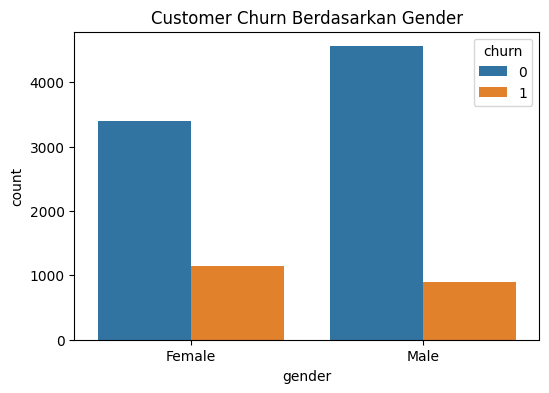

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender",
    hue="churn"
)

plt.title("Customer Churn Berdasarkan Gender")

plt.show()

In [ ]:
pd.crosstab(
    df["gender"],
    df["churn"],
    normalize="index"
)*100

churn,0,1
gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928


### Insight

Berdasarkan hasil analisis,pelanggan perempuan pada dataset ini memiliki kecenderungan lebih tinggi untuk berhenti menggunakan layanan bank dibandingkan pelanggan laki-laki. Perbedaan ini mengindikasikan bahwa terdapat faktor-faktor lain yang mungkin memengaruhi keputusan pelanggan perempuan untuk melakukan churn.

Pelanggan perempuan memiliki tingkat churn lebih tinggi pada dataset ini. Analisis lanjutan diperlukan untuk mengetahui faktor penyebabnya.

## Analisis 4 - Apakah Usia Berpengaruh terhadap Customer Churn?


Apakah terdapat perbedaan distribusi usia antara pelanggan yang tetap menggunakan layanan bank dengan pelanggan yang melakukan customer churn?

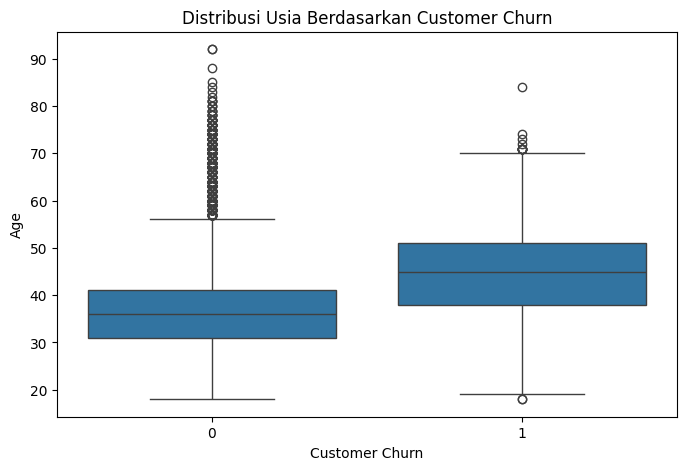

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn",
    y="age"
)

plt.title("Distribusi Usia Berdasarkan Customer Churn")
plt.xlabel("Customer Churn")
plt.ylabel("Age")

plt.show()

In [ ]:
df.groupby("churn")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,7963.0,37.408389,10.125363,18.0,31.0,36.0,41.0,92.0
1,2037.0,44.837997,9.761562,18.0,38.0,45.0,51.0,84.0


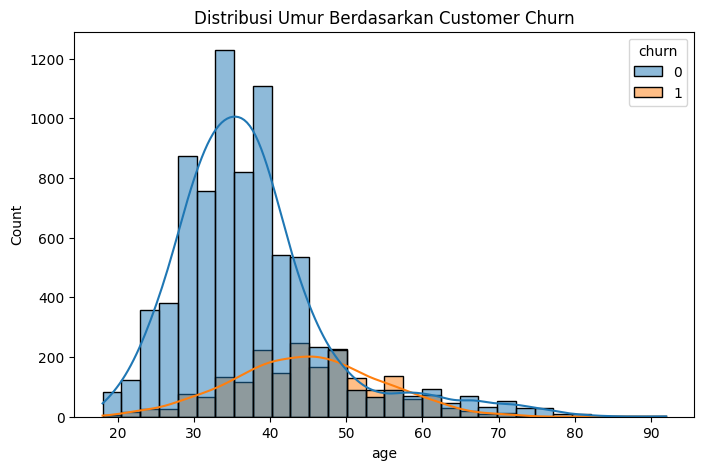

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    hue="churn",
    bins=30,
    kde=True
)

plt.title("Distribusi Umur Berdasarkan Customer Churn")

plt.show()

In [ ]:
df.groupby("churn")["age"].mean()

,age
churn,
0,37.408389
1,44.837997


### Insight

Berdasarkan hasil analisis, pelanggan yang tetap menggunakan layanan bank memiliki rata-rata usia 37,41 tahun, sedangkan pelanggan yang melakukan customer churn memiliki rata-rata usia 44,84 tahun.


## Analisis 5 - Apakah Jumlah Produk Berpengaruh terhadap Customer Churn?


Apakah jumlah produk yang dimiliki pelanggan berpengaruh terhadap kemungkinan customer churn?

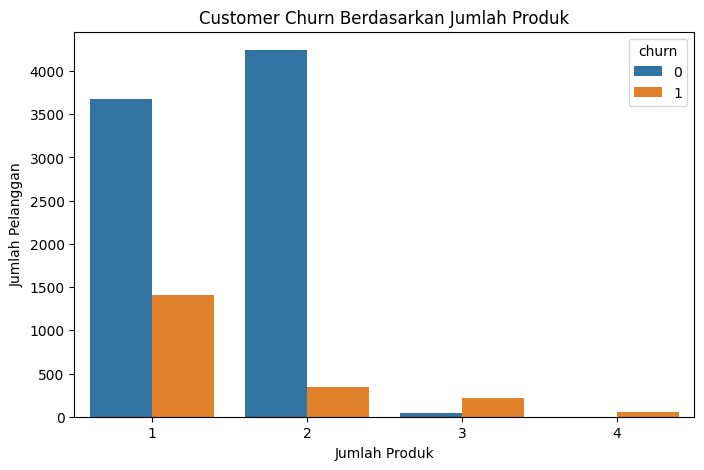

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="products_number",
    hue="churn"
)

plt.title("Customer Churn Berdasarkan Jumlah Produk")
plt.xlabel("Jumlah Produk")
plt.ylabel("Jumlah Pelanggan")

plt.show()

In [ ]:
pd.crosstab(
    df["products_number"],
    df["churn"],
    normalize="index"
)*100

churn,0,1
products_number,,
1,72.285602,27.714398
2,92.418301,7.581699
3,17.293233,82.706767
4,0.000000,100.000000


### Insight

Hasil analisis menunjukkan bahwa jumlah produk yang dimiliki pelanggan memiliki hubungan yang cukup kuat dengan customer churn.

- Pelanggan yang hanya memiliki 1 produk memiliki tingkat churn sebesar 27,71%.
- Pelanggan dengan 2 produk memiliki tingkat churn paling rendah, yaitu 7,58%**, yang menunjukkan tingkat loyalitas lebih tinggi.
- Sebaliknya, pelanggan yang memiliki 3 produk memiliki tingkat churn sangat tinggi, yaitu 82,71%.
- Seluruh pelanggan yang memiliki 4 produk pada dataset ini melakukan churn (100%). Namun, jumlah pelanggan pada kategori ini kemungkinan sangat sedikit.


### Business Recommendation

Bank dapat mendorong pelanggan yang hanya memiliki satu produk untuk menggunakan produk tambahan yang sesuai dengan kebutuhan mereka, seperti tabungan, deposito, kartu kredit, atau layanan digital.

pelanggan yang telah menggunakan tiga atau lebih produk perlu dievaluasi lebih lanjut untuk mengetahui penyebab tingginya tingkat churn. Bank dapat melakukan survei kepuasan, meningkatkan kualitas layanan, serta menawarkan program loyalitas agar pelanggan tetap mempertahankan seluruh produk yang dimiliki.

## Analisis 6 - Apakah Status Keaktifan Pelanggan Berpengaruh terhadap Customer Churn?


Apakah pelanggan yang aktif memiliki kemungkinan churn yang lebih rendah dibandingkan pelanggan yang tidak aktif?

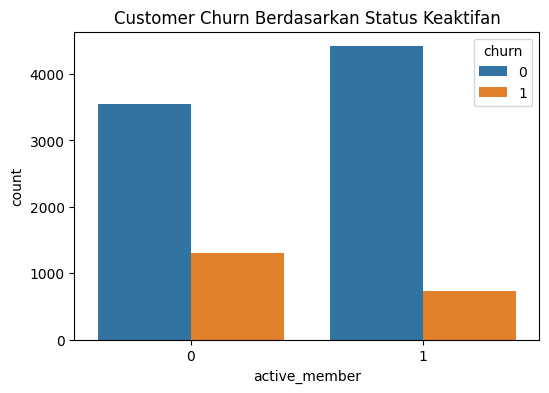

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="active_member",
    hue="churn"
)

plt.title("Customer Churn Berdasarkan Status Keaktifan")

plt.show()

In [ ]:
pd.crosstab(
    df["active_member"],
    df["churn"],
    normalize="index"
)*100

churn,0,1
active_member,,
0,73.149103,26.850897
1,85.730926,14.269074


### Insight

Berdasarkan hasil analisis, pelanggan yang tidak aktif memiliki tingkat customer churn sebesar 26,85%, sedangkan pelanggan yang aktif memiliki tingkat churn yang lebih rendah yaitu 14,27%.

Perbedaan ini menunjukkan bahwa pelanggan yang aktif menggunakan layanan bank cenderung lebih loyal dibandingkan pelanggan yang tidak aktif. Aktivitas pelanggan dapat menjadi salah satu indikator penting dalam mengidentifikasi risiko customer churn.

### Business Recommendation

Bank dapat meningkatkan keterlibatan pelanggan melalui promosi layanan digital, program loyalitas, pemberian reward atas aktivitas transaksi, maupun komunikasi yang lebih personal. Meningkatkan aktivitas pelanggan diharapkan dapat menurunkan risiko customer churn.

## Analisis 7 - Apakah Credit Score Berpengaruh terhadap Customer Churn?


Apakah terdapat perbedaan credit score antara pelanggan yang churn dan pelanggan yang tetap menggunakan layanan bank?

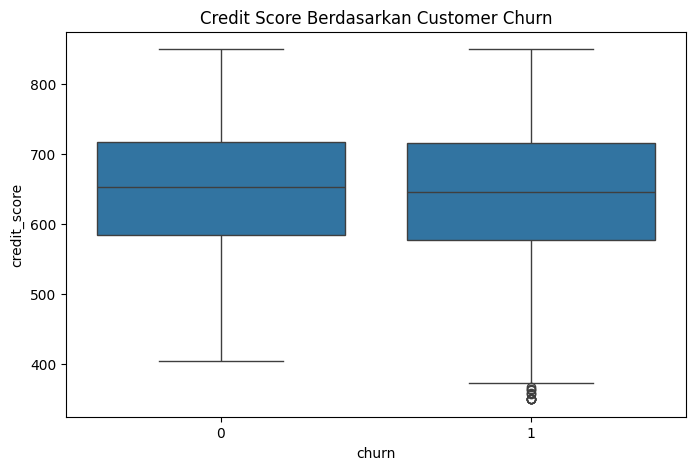

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn",
    y="credit_score"
)

plt.title("Credit Score Berdasarkan Customer Churn")

plt.show()

In [ ]:
df.groupby("churn")["credit_score"].mean()

,credit_score
churn,
0,651.853196
1,645.351497


### Insight

Rata-rata credit score pelanggan yang tetap menggunakan layanan bank adalah 651,85, sedangkan pelanggan yang melakukan churn memiliki rata-rata 645,35.

Perbedaan rata-rata tersebut relatif kecil, sehingga credit score belum menunjukkan hubungan yang kuat terhadap customer churn pada dataset ini.

## Analisis 8 - Apakah Estimasi Gaji Berpengaruh terhadap Customer Churn?

Apakah estimasi gaji pelanggan memiliki hubungan dengan customer churn?

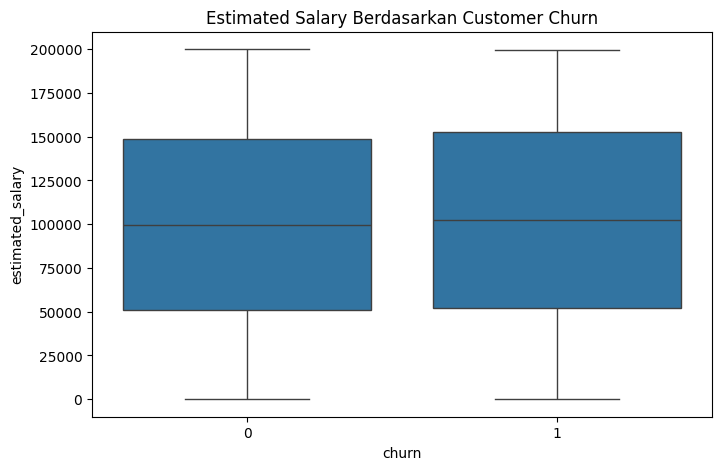

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn",
    y="estimated_salary"
)

plt.title("Estimated Salary Berdasarkan Customer Churn")

plt.show()

In [ ]:
df.groupby("churn")["estimated_salary"].mean()

,estimated_salary
churn,
0,99738.391772
1,101465.677531


### Insight

Rata-rata estimasi gaji pelanggan yang tetap menggunakan layanan bank adalah 99.738, sedangkan pelanggan yang melakukan churn memiliki rata-rata 101.466.

Perbedaan tersebut relatif kecil sehingga estimasi gaji belum menunjukkan hubungan yang signifikan dengan customer churn.

## Analisis 9 - Korelasi Antar Variabel

Bagaimana hubungan antar variabel numerik pada dataset customer churn?

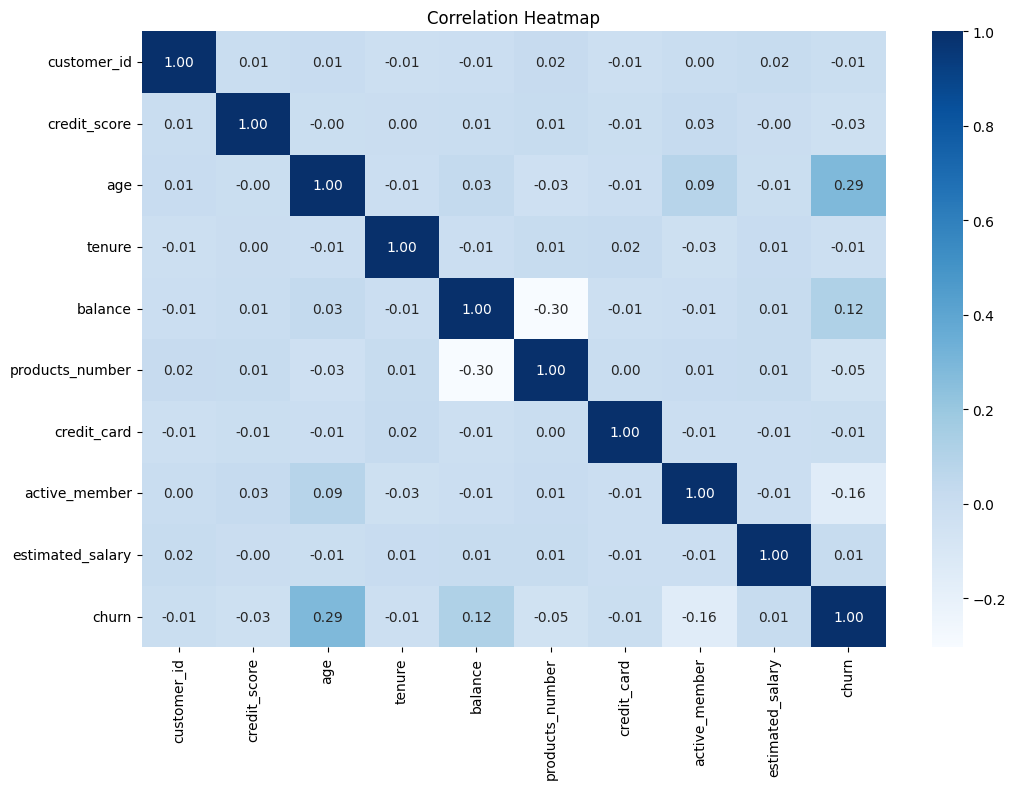

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Insight

Berdasarkan hasil correlation heatmap, sebagian besar variabel memiliki hubungan linear yang lemah terhadap customer churn. Hal ini menunjukkan bahwa keputusan pelanggan untuk berhenti menggunakan layanan bank kemungkinan dipengaruhi oleh kombinasi beberapa faktor, bukan hanya satu variabel.

Beberapa temuan utama dari analisis korelasi adalah:

- **Age** memiliki korelasi positif terbesar terhadap customer churn (**0,29**), yang menunjukkan bahwa pelanggan dengan usia lebih tinggi cenderung memiliki kemungkinan churn yang lebih besar.
- **Active Member** memiliki korelasi negatif terhadap customer churn (**-0,16**). Hal ini mengindikasikan bahwa pelanggan yang aktif menggunakan layanan bank cenderung memiliki risiko churn yang lebih rendah.
- **Balance** memiliki korelasi positif yang lemah terhadap customer churn (**0,12**), sehingga saldo rekening kemungkinan memiliki pengaruh, meskipun tidak terlalu kuat.
- **Credit Score (-0,03)**, **Estimated Salary (0,01)**, **Tenure (-0,01)**, dan **Credit Card (-0,01)** menunjukkan hubungan yang sangat lemah dengan customer churn.
- Korelasi negatif sebesar **-0,30** antara **Balance** dan **Products Number** menunjukkan bahwa pada dataset ini, pelanggan dengan saldo lebih tinggi tidak selalu memiliki jumlah produk yang lebih banyak. Temuan ini menggambarkan adanya hubungan antarvariabel, namun tidak dapat disimpulkan sebagai hubungan sebab-akibat.

# Executive Summary

Berdasarkan hasil Exploratory Data Analysis (EDA) terhadap data customer churn, diperoleh beberapa temuan utama sebagai berikut:

1. Tingkat customer churn pada dataset sebesar sekitar 20%, sehingga sebagian besar pelanggan masih bertahan menggunakan layanan bank.

2. Pelanggan dengan usia yang lebih tinggi memiliki kecenderungan churn lebih besar dibandingkan pelanggan yang lebih muda.

3. Pelanggan yang aktif menggunakan layanan bank memiliki tingkat churn yang lebih rendah dibandingkan pelanggan yang tidak aktif.

4. Pelanggan dengan dua produk memiliki tingkat churn paling rendah, sedangkan pelanggan dengan tiga atau empat produk menunjukkan tingkat churn yang jauh lebih tinggi. Temuan ini memerlukan analisis lebih lanjut karena kemungkinan dipengaruhi oleh karakteristik segmen pelanggan.

5. Credit score dan estimated salary tidak menunjukkan hubungan yang kuat terhadap customer churn.

6. Correlation heatmap menunjukkan bahwa tidak ada satu variabel yang memiliki hubungan linear yang sangat kuat terhadap customer churn, sehingga strategi retensi pelanggan perlu mempertimbangkan kombinasi beberapa faktor.